# Music Emotion Recognition using CNN Regression (PyTorch)
## DEAM Dataset — Predicting Valence & Arousal

This notebook builds a CNN regression model to predict **valence** and **arousal** 
values from audio, using **mel-spectrograms** as input features.

### Pipeline:
1. Load & merge DEAM annotations
2. Extract mel-spectrograms from audio files
3. Build a CNN regression model in PyTorch
4. Train with MSE loss
5. Evaluate with regression metrics (MSE, MAE, R², CCC)
6. Visualize predictions on the valence-arousal plane


In [3]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm
import pickle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print("All libraries imported successfully!")


Using device: cuda
PyTorch version: 2.10.0+cu128
All libraries imported successfully!


## 1. Load DEAM Annotations


In [4]:
# Mencari nama folder dataset pertama yang ada di /kaggle/input/
input_folders = os.listdir('/kaggle/input')
if input_folders:
    BASE_DIR = os.path.join('/kaggle/input', input_folders[0])
    print(f"BASE_DIR otomatis: {BASE_DIR}")

BASE_DIR otomatis: /kaggle/input/datasets


In [5]:
import os
import pandas as pd

# === Dataset Paths (Kaggle Version) ===
# Menggunakan path Kaggle yang sudah berhasil terdeteksi sebelumnya
BASE_DIR = "/kaggle/input/datasets/imsparsh/deam-mediaeval-dataset-emotional-analysis-in-music"
AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")
ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
                         "annotations averaged per song", "song_level")

# --- Load annotation CSVs ---
annot_file_1 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_1_2000.csv")
annot_file_2 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_2000_2058.csv")

# Pastikan kedua file ada sebelum diproses
if os.path.exists(annot_file_1) and os.path.exists(annot_file_2):
    df1 = pd.read_csv(annot_file_1)
    df2 = pd.read_csv(annot_file_2)

    # Standardize column names (strip whitespace)
    df1.columns = df1.columns.str.strip()
    df2.columns = df2.columns.str.strip()

    # Select common columns
    common_cols = ['song_id', 'valence_mean', 'valence_std', 'arousal_mean', 'arousal_std']
    
    # Gunakan .loc jika ada peringatan untuk memastikan tidak terjadi SettingWithCopyWarning
    df1_sel = df1.loc[:, common_cols].copy()
    df2_sel = df2.loc[:, common_cols].copy()

    # Merge both annotation dataframes
    annotations = pd.concat([df1_sel, df2_sel], ignore_index=True)
    annotations = annotations.drop_duplicates(subset='song_id').reset_index(drop=True)

    print("✅ Berhasil memuat dan menggabungkan data!")
    print(f"Total annotated songs: {len(annotations)}")
    print(f"\nMissing values:\n{annotations.isnull().sum()}")
    print(f"\n--- Descriptive Statistics ---")
    
    # Gunakan display() agar tabel statistik tampil lebih rapi di Kaggle
    display(annotations[['valence_mean', 'arousal_mean']].describe())
    
else:
    print("❌ ERROR: File CSV tidak ditemukan.")
    print(f"Cek path: {annot_file_1}")

✅ Berhasil memuat dan menggabungkan data!
Total annotated songs: 1802

Missing values:
song_id         0
valence_mean    0
valence_std     0
arousal_mean    0
arousal_std     0
dtype: int64

--- Descriptive Statistics ---


,valence_mean,arousal_mean
count,1802.000000,1802.000000
mean,4.904145,4.814029
std,1.174240,1.282187
min,1.600000,1.600000
25%,4.100000,3.800000
50%,4.900000,4.900000
75%,5.800000,5.800000
max,8.400000,8.100000


## 2. Match Audio Files with Annotations


Total audio files found: 1802
Annotated songs with audio: 1802


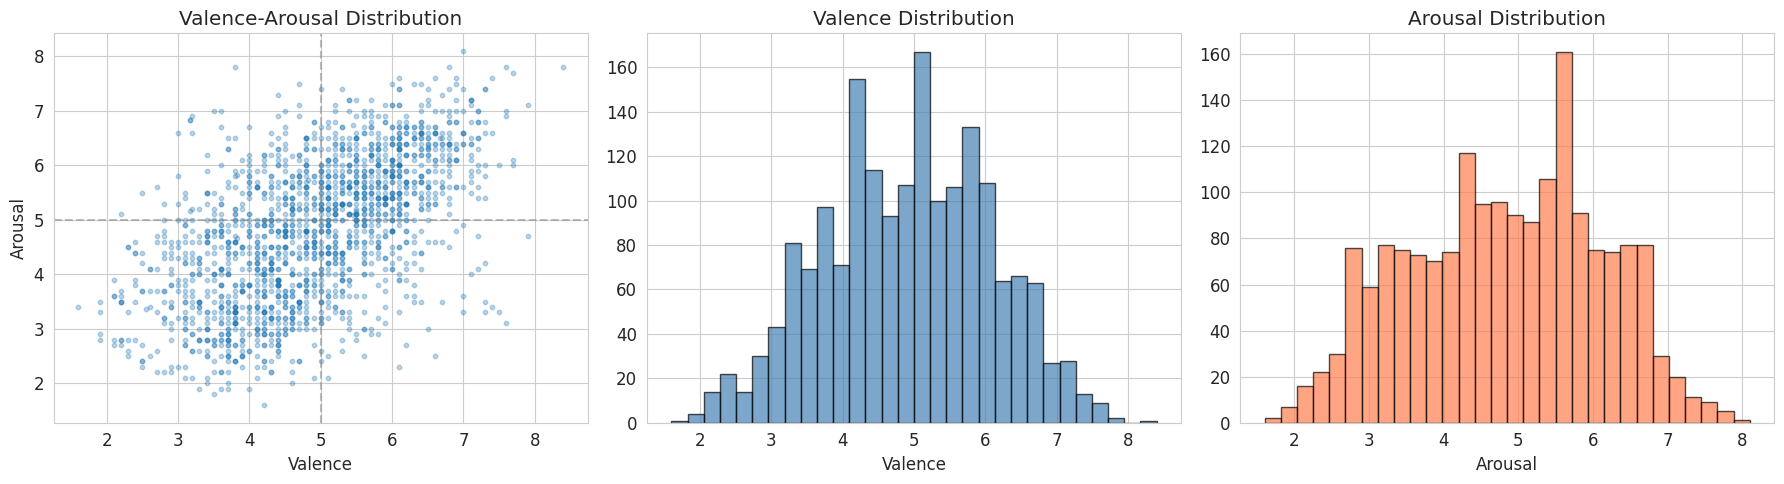

In [6]:
# Find available audio files
audio_files = [f for f in os.listdir(AUDIO_DIR) if f.endswith('.mp3') or f.endswith('.wav')]
audio_ids = set()
for f in audio_files:
    try:
        song_id = int(f.split('.')[0])
        audio_ids.add(song_id)
    except ValueError:
        continue

print(f"Total audio files found: {len(audio_ids)}")

# Filter annotations to only include songs with audio
annotations = annotations[annotations['song_id'].isin(audio_ids)].reset_index(drop=True)
print(f"Annotated songs with audio: {len(annotations)}")

# Visualize valence-arousal distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot
axes[0].scatter(annotations['valence_mean'], annotations['arousal_mean'], alpha=0.3, s=10)
axes[0].set_xlabel('Valence')
axes[0].set_ylabel('Arousal')
axes[0].set_title('Valence-Arousal Distribution')
axes[0].axhline(y=5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=5, color='gray', linestyle='--', alpha=0.5)

# Valence histogram
axes[1].hist(annotations['valence_mean'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Valence')
axes[1].set_title('Valence Distribution')

# Arousal histogram
axes[2].hist(annotations['arousal_mean'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[2].set_xlabel('Arousal')
axes[2].set_title('Arousal Distribution')

plt.tight_layout()
plt.show()


## 3. Extract Mel-Spectrograms from Audio

We extract **log-mel-spectrograms** which are proven to be effective features 
for music emotion recognition. Each audio file is cropped to a fixed duration 
and converted into a 2D time-frequency representation.


Extracting features (mel + chroma) to disk (or finding existing ones)...


Extracting: 100%|██████████| 1802/1802 [10:29<00:00,  2.86it/s]



Extracted/Found 1802 mel-spectrograms.

Valid dataset size: 1802 songs


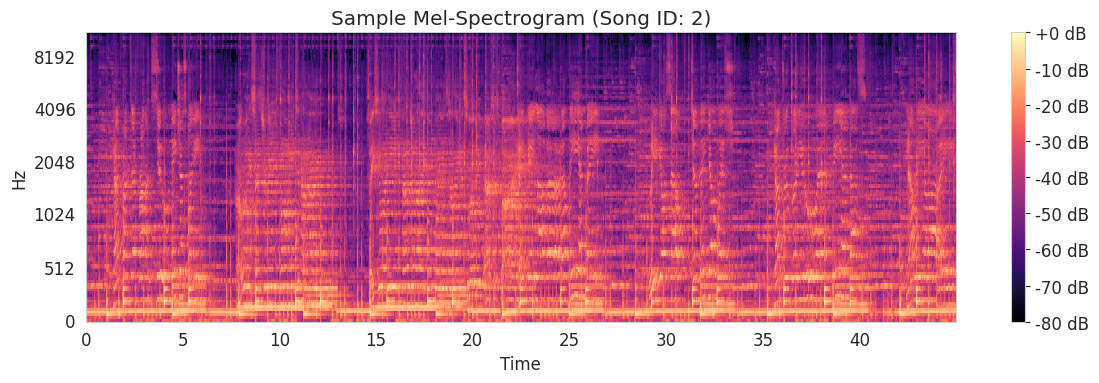

In [7]:
# === Mel-spectrogram extraction parameters ===
SR = 22050          # Sample rate
DURATION = 45       # Crop duration in seconds 
N_MELS = 128        # Number of mel bands
HOP_LENGTH = 512    # Hop length
N_FFT = 2048        # FFT window size

MELSPEC_DIR = "deam_features_v2_cache"  # v2: mel + chroma (2 channels)
os.makedirs(MELSPEC_DIR, exist_ok=True)

from scipy.ndimage import zoom as _scipy_zoom

def extract_mel_spectrogram(file_path, sr=SR, duration=DURATION, 
                            n_mels=N_MELS, hop_length=HOP_LENGTH, n_fft=N_FFT):
    """Extract a log-mel-spectrogram from an audio file."""
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=sr, mono=True)
        
        # Crop to middle 'duration' seconds
        total_samples = len(y)
        target_samples = sr * duration
        
        if total_samples >= target_samples:
            start = (total_samples - target_samples) // 2
            y = y[start:start + target_samples]
        else:
            # Pad if shorter
            pad_len = target_samples - total_samples
            y = np.pad(y, (pad_len // 2, pad_len - pad_len // 2), mode='constant')
        
        # Extract mel-spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=n_mels, hop_length=hop_length, n_fft=n_fft
        )
        
        # Convert to log scale (dB)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        
        # --- Fix 2: Compute chroma features (tonal info improves valence) ---
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
        # Resize chroma from (12, T) to (n_mels, T) to match mel dimensions
        chroma_resized = _scipy_zoom(chroma, (n_mels / 12, 1), order=1)
        # Stack mel + chroma as 2-channel array: shape (2, n_mels, T)
        features = np.stack([log_mel_spec, chroma_resized], axis=0)
        return features
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

print("Extracting features (mel + chroma) to disk (or finding existing ones)...")
melspec_paths = []
valid_indices = []

for idx, row in tqdm(annotations.iterrows(), total=len(annotations), desc="Extracting"):
    song_id = int(row['song_id'])
    
    save_path = os.path.join(MELSPEC_DIR, f"{song_id}.npy")
    
    # Check if already processed
    if os.path.exists(save_path):
        melspec_paths.append(save_path)
        valid_indices.append(idx)
        continue
        
    # Try different extensions
    audio_path = None
    for ext in ['.mp3', '.wav']:
        candidate = os.path.join(AUDIO_DIR, f"{song_id}{ext}")
        if os.path.exists(candidate):
            audio_path = candidate
            break
    
    if audio_path is None:
        continue
    
    mel_spec = extract_mel_spectrogram(audio_path)
    if mel_spec is not None:
        np.save(save_path, mel_spec)
        melspec_paths.append(save_path)
        valid_indices.append(idx)

print(f"\nExtracted/Found {len(melspec_paths)} mel-spectrograms.")

# Filter annotations to valid entries only
annotations_valid = annotations.iloc[valid_indices].reset_index(drop=True)
print(f"\nValid dataset size: {len(annotations_valid)} songs")

# Show a sample mel-spectrogram
if len(melspec_paths) > 0:
    sample_melspec = np.load(melspec_paths[0])[0]  # channel 0 = mel-spectrogram
    fig, ax = plt.subplots(figsize=(12, 4))
    img = librosa.display.specshow(sample_melspec, sr=SR, hop_length=HOP_LENGTH, 
                             x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(f"Sample Mel-Spectrogram (Song ID: {int(annotations_valid.iloc[0]['song_id'])})")
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

## 4. PyTorch Dataset & DataLoader


In [8]:
class DEAMDataset(Dataset):
    """PyTorch Dataset for DEAM mel-spectrograms with valence/arousal targets."""
    
    def __init__(self, melspec_paths, valence, arousal, training=False):
        self.melspec_paths = melspec_paths
        self.valence = valence
        self.arousal = arousal
        self.training = training
    
    def __len__(self):
        return len(self.melspec_paths)
    
    def __getitem__(self, idx):
        # Load features from disk — shape: (2, n_mels, time_steps)
        path = self.melspec_paths[idx]
        features = np.load(path).astype(np.float32)
        features = torch.FloatTensor(features)  # already (C, H, W)
        
        # Normalize each channel independently to [0, 1]
        for c in range(features.shape[0]):
            ch = features[c]
            ch_min, ch_max = ch.min(), ch.max()
            if ch_max - ch_min > 0:
                features[c] = (ch - ch_min) / (ch_max - ch_min)
        
        # --- Fix 3: SpecAugment (training only) ---
        if self.training:
            features = self._spec_augment(features)
        
        # Targets
        targets = torch.FloatTensor([self.valence[idx], self.arousal[idx]])
        
        return features, targets
    
    def _spec_augment(self, spec):
        """Apply SpecAugment: frequency masking + time masking."""
        _, n_freq, n_time = spec.shape
        
        # Frequency masking (mask a random band of frequency bins)
        if torch.rand(1).item() < 0.5:
            f = torch.randint(1, min(20, n_freq) + 1, (1,)).item()
            f0 = torch.randint(0, max(1, n_freq - f), (1,)).item()
            spec[:, f0:f0 + f, :] = 0.0
        
        # Time masking (mask a random span of time frames)
        if torch.rand(1).item() < 0.5:
            t = torch.randint(1, min(30, n_time) + 1, (1,)).item()
            t0 = torch.randint(0, max(1, n_time - t), (1,)).item()
            spec[:, :, t0:t0 + t] = 0.0
        
        return spec

# Prepare data
X = np.array(melspec_paths)
y_valence = annotations_valid['valence_mean'].values.astype(np.float32)
y_arousal = annotations_valid['arousal_mean'].values.astype(np.float32)

# Normalize targets to [0, 1] range (original range is 1-9)
# We'll use min-max normalization based on the theoretical range
TARGET_MIN = 1.0
TARGET_MAX = 9.0
y_valence_norm = (y_valence - TARGET_MIN) / (TARGET_MAX - TARGET_MIN)
y_arousal_norm = (y_arousal - TARGET_MIN) / (TARGET_MAX - TARGET_MIN)

# Train/Val/Test split: 70% / 15% / 15%
X_train, X_temp, y_v_train, y_v_temp, y_a_train, y_a_temp = train_test_split(
    X, y_valence_norm, y_arousal_norm, test_size=0.2, random_state=42
)
X_val, X_test, y_v_val, y_v_test, y_a_val, y_a_test = train_test_split(
    X_temp, y_v_temp, y_a_temp, test_size=0.5, random_state=42
)

total_samples = len(X)
train_pct = len(X_train) / total_samples * 100
val_pct = len(X_val) / total_samples * 100
test_pct = len(X_test) / total_samples * 100

print(f"Train: {len(X_train)} ({train_pct:.1f}%), "
      f"Val: {len(X_val)} ({val_pct:.1f}%), "
      f"Test: {len(X_test)} ({test_pct:.1f}%)")
print(f"Saving to disk approach ensures lower RAM usage.")

# Create datasets
train_dataset = DEAMDataset(X_train, y_v_train, y_a_train, training=True)   # SpecAugment ON
val_dataset = DEAMDataset(X_val, y_v_val, y_a_val, training=False)
test_dataset = DEAMDataset(X_test, y_v_test, y_a_test, training=False)

# Create dataloaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Verify shapes
for specs, targets in train_loader:
    print(f"Batch spectrogram shape: {specs.shape}")
    print(f"Batch targets shape: {targets.shape}")
    break

Train: 1441 (80.0%), Val: 180 (10.0%), Test: 181 (10.0%)
Saving to disk approach ensures lower RAM usage.
Batch spectrogram shape: torch.Size([16, 2, 128, 1938])
Batch targets shape: torch.Size([16, 2])


## 5. CNN Regression Model

A CNN architecture designed for music emotion regression:
- Multiple convolutional blocks with batch normalization
- Global Average Pooling to handle variable-length spectrograms
- Fully connected regression head outputting valence & arousal


In [9]:
class MusicEmotionCNN(nn.Module):
    """CNN model for predicting valence and arousal from mel-spectrograms."""
    
    def __init__(self, n_mels=128):
        super(MusicEmotionCNN, self).__init__()
        
        # Convolutional blocks
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, padding=1),   # Fix 2: 2 channels (mel + chroma),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25)
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25)
        )
        
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.25)
        )
        
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully connected regression head
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 2),    # 2 outputs: valence, arousal
            # (Fix 1: Sigmoid removed — linear output + clamp at inference)
        )
    
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        
        x = self.fc(x)
        # Fix 1: clamp predictions to [0, 1] at inference (no gradient saturation)
        if not self.training:
            x = torch.clamp(x, 0.0, 1.0)
        return x

# Instantiate model
model = MusicEmotionCNN(n_mels=N_MELS).to(device)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


MusicEmotionCNN(
  (conv_block1): Sequential(
    (0): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_si

## 6. Training Loop


In [10]:
def concordance_correlation_coefficient(y_true, y_pred):
    """Compute the Concordance Correlation Coefficient (CCC)."""
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    covariance = np.mean((y_true - mean_true) * (y_pred - mean_pred))
    ccc = (2 * covariance) / (var_true + var_pred + (mean_true - mean_pred) ** 2 + 1e-8)
    return ccc

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_targets = []
    
    for specs, targets in train_loader:
        specs = specs.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(specs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * specs.size(0)
        all_preds.append(outputs.detach().cpu().numpy())
        all_targets.append(targets.cpu().numpy())
    
    epoch_loss = running_loss / len(train_loader.dataset)
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    
    return epoch_loss, all_preds, all_targets

def evaluate(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for specs, targets in data_loader:
            specs = specs.to(device)
            targets = targets.to(device)
            
            outputs = model(specs)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item() * specs.size(0)
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
    
    epoch_loss = running_loss / len(data_loader.dataset)
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    
    return epoch_loss, all_preds, all_targets

# Training configuration
NUM_EPOCHS = 150
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 25       # Early stopping patience

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

from torch.optim.lr_scheduler import SequentialLR, LinearLR, ReduceLROnPlateau

# Warm-up: ramp LR from 0.2× to 1.0× over 5 epochs
warmup = LinearLR(optimizer, start_factor=0.2, end_factor=1.0, total_iters=5)
# Plateau: halve LR when val loss stops improving
plateau = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7)

# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'val_valence_mse': [], 'val_arousal_mse': [],
    'val_valence_ccc': [], 'val_arousal_ccc': [],
    'lr': []
}

best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

print(f"Starting training for {NUM_EPOCHS} epochs...")
print(f"Learning rate: {LEARNING_RATE}, Weight decay: {WEIGHT_DECAY}")
print(f"Early stopping patience: {PATIENCE}")
print("=" * 80)

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss, train_preds, train_targets = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Validate
    val_loss, val_preds, val_targets = evaluate(model, val_loader, criterion, device)
    
    # Compute per-dimension metrics
    val_v_mse = mean_squared_error(val_targets[:, 0], val_preds[:, 0])
    val_a_mse = mean_squared_error(val_targets[:, 1], val_preds[:, 1])
    val_v_ccc = concordance_correlation_coefficient(val_targets[:, 0], val_preds[:, 0])
    val_a_ccc = concordance_correlation_coefficient(val_targets[:, 1], val_preds[:, 1])
    
    current_lr = optimizer.param_groups[0]['lr']
    
    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_valence_mse'].append(val_v_mse)
    history['val_arousal_mse'].append(val_a_mse)
    history['val_valence_ccc'].append(val_v_ccc)
    history['val_arousal_ccc'].append(val_a_ccc)
    history['lr'].append(current_lr)
    
    # Learning rate scheduling
    if epoch < 5:
        warmup.step()
    else:
        plateau.step(val_loss)
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        marker = " ⭐ (best)"
    else:
        patience_counter += 1
        marker = ""
    
    if (epoch + 1) % 5 == 0 or epoch == 0 or marker:
        print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] | "
              f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | "
              f"V_CCC: {val_v_ccc:.4f} | A_CCC: {val_a_ccc:.4f} | "
              f"LR: {current_lr:.6f}{marker}")
    
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(best_model_state)
print(f"\nBest validation loss: {best_val_loss:.6f}")

# Save the best model
torch.save(best_model_state, "best_cnn_regression.pth")
print("Best model saved to best_cnn_regression.pth")

Starting training for 150 epochs...
Learning rate: 0.001, Weight decay: 0.0001
Early stopping patience: 25
Epoch [  1/150] | Train Loss: 0.074273 | Val Loss: 0.026640 | V_CCC: 0.3010 | A_CCC: 0.3831 | LR: 0.000200 ⭐ (best)
Epoch [  2/150] | Train Loss: 0.042075 | Val Loss: 0.018302 | V_CCC: 0.4016 | A_CCC: 0.4487 | LR: 0.000360 ⭐ (best)
Epoch [  3/150] | Train Loss: 0.033730 | Val Loss: 0.017581 | V_CCC: 0.3954 | A_CCC: 0.4641 | LR: 0.000520 ⭐ (best)
Epoch [  5/150] | Train Loss: 0.028371 | Val Loss: 0.022079 | V_CCC: 0.2956 | A_CCC: 0.3980 | LR: 0.000840
Epoch [  6/150] | Train Loss: 0.026269 | Val Loss: 0.016604 | V_CCC: 0.3631 | A_CCC: 0.4891 | LR: 0.001000 ⭐ (best)
Epoch [  7/150] | Train Loss: 0.024404 | Val Loss: 0.015317 | V_CCC: 0.4145 | A_CCC: 0.4909 | LR: 0.001000 ⭐ (best)
Epoch [ 10/150] | Train Loss: 0.021012 | Val Loss: 0.018052 | V_CCC: 0.3814 | A_CCC: 0.4566 | LR: 0.001000
Epoch [ 11/150] | Train Loss: 0.019809 | Val Loss: 0.014809 | V_CCC: 0.4317 | A_CCC: 0.4865 | LR: 0

## 7. Training Curves


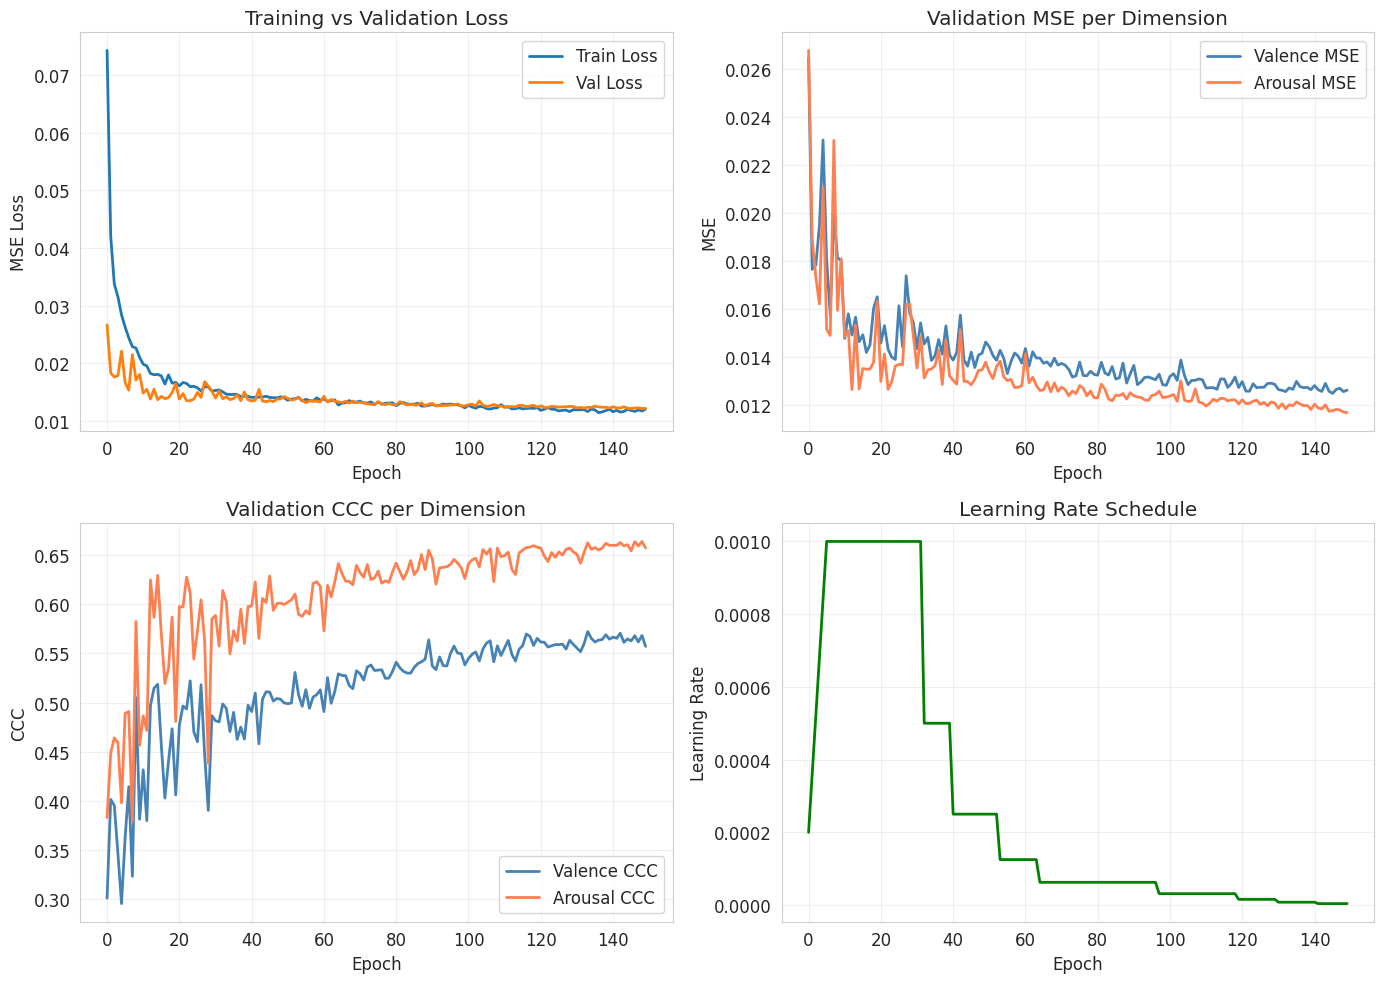

Training curves saved to training_curves.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss curves
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].set_title('Training vs Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Per-dimension MSE
axes[0, 1].plot(history['val_valence_mse'], label='Valence MSE', linewidth=2, color='steelblue')
axes[0, 1].plot(history['val_arousal_mse'], label='Arousal MSE', linewidth=2, color='coral')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MSE')
axes[0, 1].set_title('Validation MSE per Dimension')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# CCC curves
axes[1, 0].plot(history['val_valence_ccc'], label='Valence CCC', linewidth=2, color='steelblue')
axes[1, 0].plot(history['val_arousal_ccc'], label='Arousal CCC', linewidth=2, color='coral')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('CCC')
axes[1, 0].set_title('Validation CCC per Dimension')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning rate
axes[1, 1].plot(history['lr'], linewidth=2, color='green')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved to training_curves.png")


## 8. Test Set Evaluation


In [12]:
# ===================================================================
# Fix 4: Test-time averaging (TTA) — averages over augmented passes
# ===================================================================
def evaluate_with_tta(model, loader, criterion, device):
    """TTA: average predictions from 5 different time shifts."""
    model.eval()
    shifts = [0, 100, -100, 200, -200]  # frame shifts along time axis
    all_preds_per_shift = []
    all_targets = None

    for shift in shifts:
        preds_list, tgt_list = [], []
        with torch.no_grad():
            for specs, targets in loader:
                specs = specs.to(device)
                if shift != 0:
                    specs = torch.roll(specs, shifts=shift, dims=3)
                out = model(specs)
                preds_list.append(out.cpu().numpy())
                tgt_list.append(targets.numpy())
        all_preds_per_shift.append(np.concatenate(preds_list))
        if all_targets is None:
            all_targets = np.concatenate(tgt_list)

    avg_preds = np.mean(all_preds_per_shift, axis=0)
    return avg_preds, all_targets

# Evaluate on test set with TTA
print("Evaluating on test set with TTA (time shifts)...")
test_preds, test_targets = evaluate_with_tta(
    model, test_loader, criterion, device
)

# Denormalize predictions and targets back to original [1, 9] scale
test_preds_orig = test_preds * (TARGET_MAX - TARGET_MIN) + TARGET_MIN
test_targets_orig = test_targets * (TARGET_MAX - TARGET_MIN) + TARGET_MIN

# ===================================================================
# Fix 5: Report BOTH normalised and denormalised metrics
# ===================================================================

# --- Normalised metrics (scale [0, 1]) ---
print(f"\n{'=' * 60}")
print(f"  NORMALISED METRICS  (scale [0, 1])")
print(f"{'=' * 60}")
for i, dim_name in enumerate(['Valence', 'Arousal']):
    mse  = mean_squared_error(test_targets[:, i], test_preds[:, i])
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(test_targets[:, i], test_preds[:, i])
    r2   = r2_score(test_targets[:, i], test_preds[:, i])
    ccc  = concordance_correlation_coefficient(test_targets[:, i], test_preds[:, i])
    
    print(f"\n  {dim_name} (normalised [0,1]):")
    print(f"    MSE:  {mse:.6f}")
    print(f"    RMSE: {rmse:.6f}")
    print(f"    MAE:  {mae:.6f}")
    print(f"    R²:   {r2:.4f}")
    print(f"    CCC:  {ccc:.4f}")

# --- Denormalised metrics (original scale [1, 9]) ---
print(f"\n{'=' * 60}")
print(f"  DENORMALISED METRICS  (original scale [1, 9])")
print(f"{'=' * 60}")
for i, dim_name in enumerate(['Valence', 'Arousal']):
    mse  = mean_squared_error(test_targets_orig[:, i], test_preds_orig[:, i])
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(test_targets_orig[:, i], test_preds_orig[:, i])
    r2   = r2_score(test_targets_orig[:, i], test_preds_orig[:, i])
    ccc  = concordance_correlation_coefficient(test_targets_orig[:, i], test_preds_orig[:, i])
    
    print(f"\n  {dim_name} (denormalised [1,9]):")
    print(f"    MSE:  {mse:.4f}")
    print(f"    RMSE: {rmse:.4f}")
    print(f"    MAE:  {mae:.4f}")
    print(f"    R²:   {r2:.4f}")
    print(f"    CCC:  {ccc:.4f}")

Evaluating on test set with TTA (time shifts)...

  NORMALISED METRICS  (scale [0, 1])

  Valence (normalised [0,1]):
    MSE:  0.010505
    RMSE: 0.102493
    MAE:  0.082409
    R²:   0.5200
    CCC:  0.6663

  Arousal (normalised [0,1]):
    MSE:  0.010038
    RMSE: 0.100191
    MAE:  0.077475
    R²:   0.5759
    CCC:  0.7258

  DENORMALISED METRICS  (original scale [1, 9])

  Valence (denormalised [1,9]):
    MSE:  0.6723
    RMSE: 0.8199
    MAE:  0.6593
    R²:   0.5200
    CCC:  0.6663

  Arousal (denormalised [1,9]):
    MSE:  0.6424
    RMSE: 0.8015
    MAE:  0.6198
    R²:   0.5759
    CCC:  0.7258


## 9. Prediction Visualization


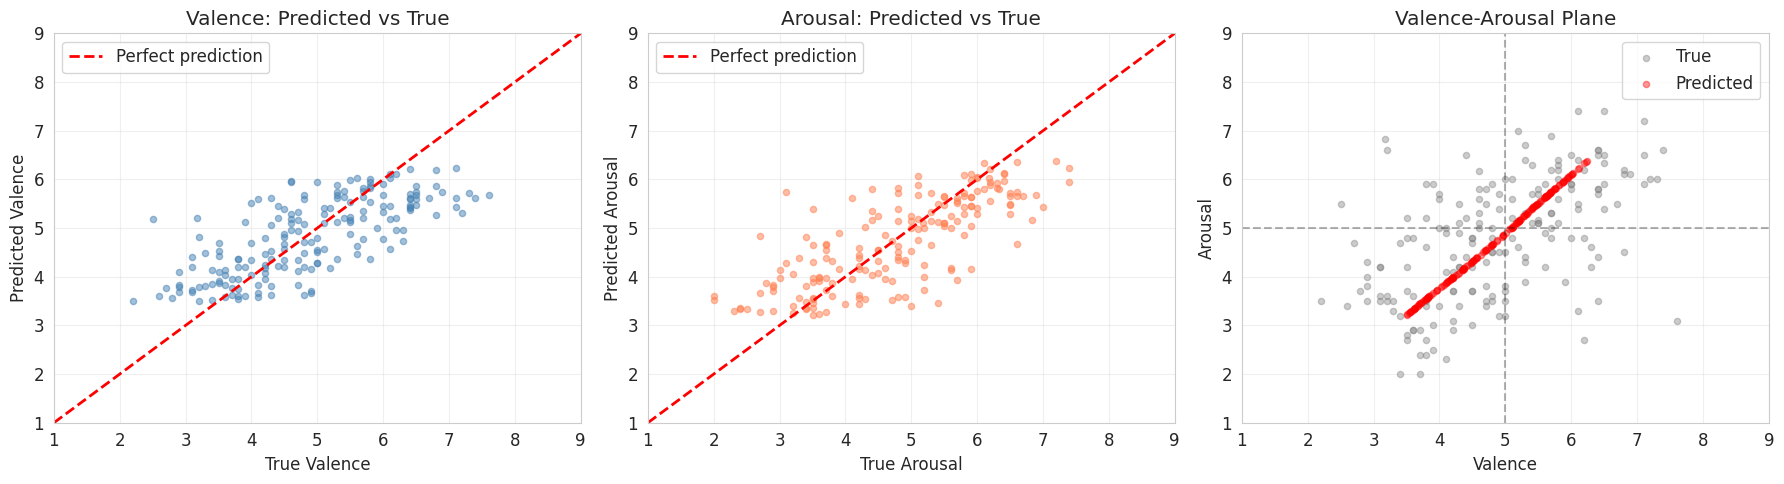

Prediction results saved to prediction_results.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Valence: Predicted vs True ---
axes[0].scatter(test_targets_orig[:, 0], test_preds_orig[:, 0], alpha=0.5, s=20, color='steelblue')
axes[0].plot([1, 9], [1, 9], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('True Valence')
axes[0].set_ylabel('Predicted Valence')
axes[0].set_title('Valence: Predicted vs True')
axes[0].set_xlim(1, 9)
axes[0].set_ylim(1, 9)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Arousal: Predicted vs True ---
axes[1].scatter(test_targets_orig[:, 1], test_preds_orig[:, 1], alpha=0.5, s=20, color='coral')
axes[1].plot([1, 9], [1, 9], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('True Arousal')
axes[1].set_ylabel('Predicted Arousal')
axes[1].set_title('Arousal: Predicted vs True')
axes[1].set_xlim(1, 9)
axes[1].set_ylim(1, 9)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Valence-Arousal Plane ---
axes[2].scatter(test_targets_orig[:, 0], test_targets_orig[:, 1], 
               alpha=0.4, s=20, label='True', color='gray')
axes[2].scatter(test_preds_orig[:, 0], test_preds_orig[:, 1], 
               alpha=0.4, s=20, label='Predicted', color='red')
axes[2].set_xlabel('Valence')
axes[2].set_ylabel('Arousal')
axes[2].set_title('Valence-Arousal Plane')
axes[2].axhline(y=5, color='black', linestyle='--', alpha=0.3)
axes[2].axvline(x=5, color='black', linestyle='--', alpha=0.3)
axes[2].set_xlim(1, 9)
axes[2].set_ylim(1, 9)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Prediction results saved to prediction_results.png")


## 10. Error Distribution Analysis


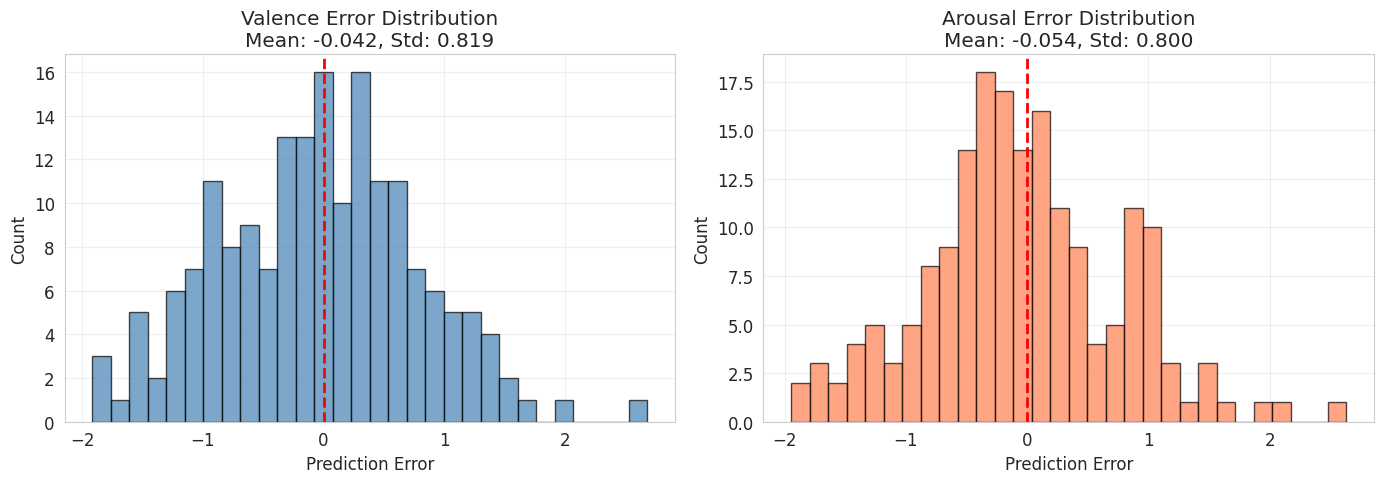

Error distribution saved to error_distribution.png


✅ Pipeline complete! Model trained and evaluated successfully.


In [14]:
# Compute errors
valence_errors = test_preds_orig[:, 0] - test_targets_orig[:, 0]
arousal_errors = test_preds_orig[:, 1] - test_targets_orig[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Valence error distribution
axes[0].hist(valence_errors, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Prediction Error')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Valence Error Distribution\nMean: {np.mean(valence_errors):.3f}, Std: {np.std(valence_errors):.3f}')
axes[0].grid(True, alpha=0.3)

# Arousal error distribution
axes[1].hist(arousal_errors, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Arousal Error Distribution\nMean: {np.mean(arousal_errors):.3f}, Std: {np.std(arousal_errors):.3f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Error distribution saved to error_distribution.png")

print("\n\n✅ Pipeline complete! Model trained and evaluated successfully.")
